In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [20]:
def logit(p):
    """Compute the logit of a probability p."""
    return np.log(p / (1 - p))

In [44]:
spliceai_preds = pd.read_csv("spliceai_minigene_snvs.csv")
exonic_variants = pd.read_csv("exonic_variants.csv")
wt_exons = pd.read_csv("wt_exons.csv")

In [45]:
spliceai_preds['spliceai_mut_donor_logit'] = logit(spliceai_preds['spliceai_minigene_donor_mut'])
spliceai_preds['spliceai_mut_acceptor_logit'] = logit(spliceai_preds['spliceai_minigene_acceptor_mut'])
spliceai_preds['spliceai_mean_logit'] = spliceai_preds[['spliceai_mut_donor_logit', 'spliceai_mut_acceptor_logit']].mean(axis=1)
spliceai_preds['spliceai_prod_logit'] = logit(spliceai_preds['spliceai_minigene_donor_mut'] * spliceai_preds['spliceai_minigene_acceptor_mut'])

spliceai_preds = spliceai_preds.merge(exonic_variants[['logit_psi', 'psi', 'se_psi', 'variant_id', 'psi_r1', 'psi_r2', 'psi_r3']], on='variant_id', how='left').sort_values('logit_psi').dropna()

In [23]:
from matplotlib.colors import LogNorm
from scipy.stats import linregress, pearsonr, spearmanr

def plot_spliceai_vs_psi(
    df,
    wt_exons,
    exon_id,
    wt_psi_col="psi",
    bins=50,
    kind="hist2d",
    figsize=(6, 5),
):
    plot_df = (
        df.loc[
            df["exon_id"].eq(exon_id),
            ["spliceai_prod_logit", "logit_psi"],
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    wt_row = wt_exons.loc[wt_exons["exon_id"].eq(exon_id)].iloc[0]
    wt_psi = wt_row[wt_psi_col]
    wt_exon_length = wt_row["exon_length"]
    x = plot_df["spliceai_prod_logit"]
    y = plot_df["logit_psi"]

    pearson_r = pearsonr(x, y).statistic
    spearman_rho = spearmanr(x, y).statistic
    slope = linregress(x, y).slope

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True,
        dpi=500,
    )
    fig.suptitle(
        f"{exon_id}: SpliceAI vs. measured PSI\n"
        f"WT PSI = {wt_psi:.3f} | WT exon length = {wt_exon_length} nt | n = {len(plot_df):,}"
    )

    if kind == "hist2d":
        hist = ax.hist2d(
            x,
            y,
            bins=bins,
            cmap="Blues",
            cmin=1,
            norm=LogNorm(),
        )
        fig.colorbar(hist[3], ax=ax, label="Count")
    elif kind == "scatter":
        ax.scatter(x, y, s=4, alpha=0.5)
    else:
        raise ValueError("kind must be 'hist2d' or 'scatter'")

    ax.text(
        0.02,
        0.98,
        f"Slope = {slope:.3f}\n"
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_rho:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
    )
    ax.set_xlabel(
        "SpliceAI product logit score:\n"
        "logit(P(acceptor) × P(donor))"
    )
    ax.set_ylabel("Measured logit PSI")
    ax.set_box_aspect(1)

    return fig, ax

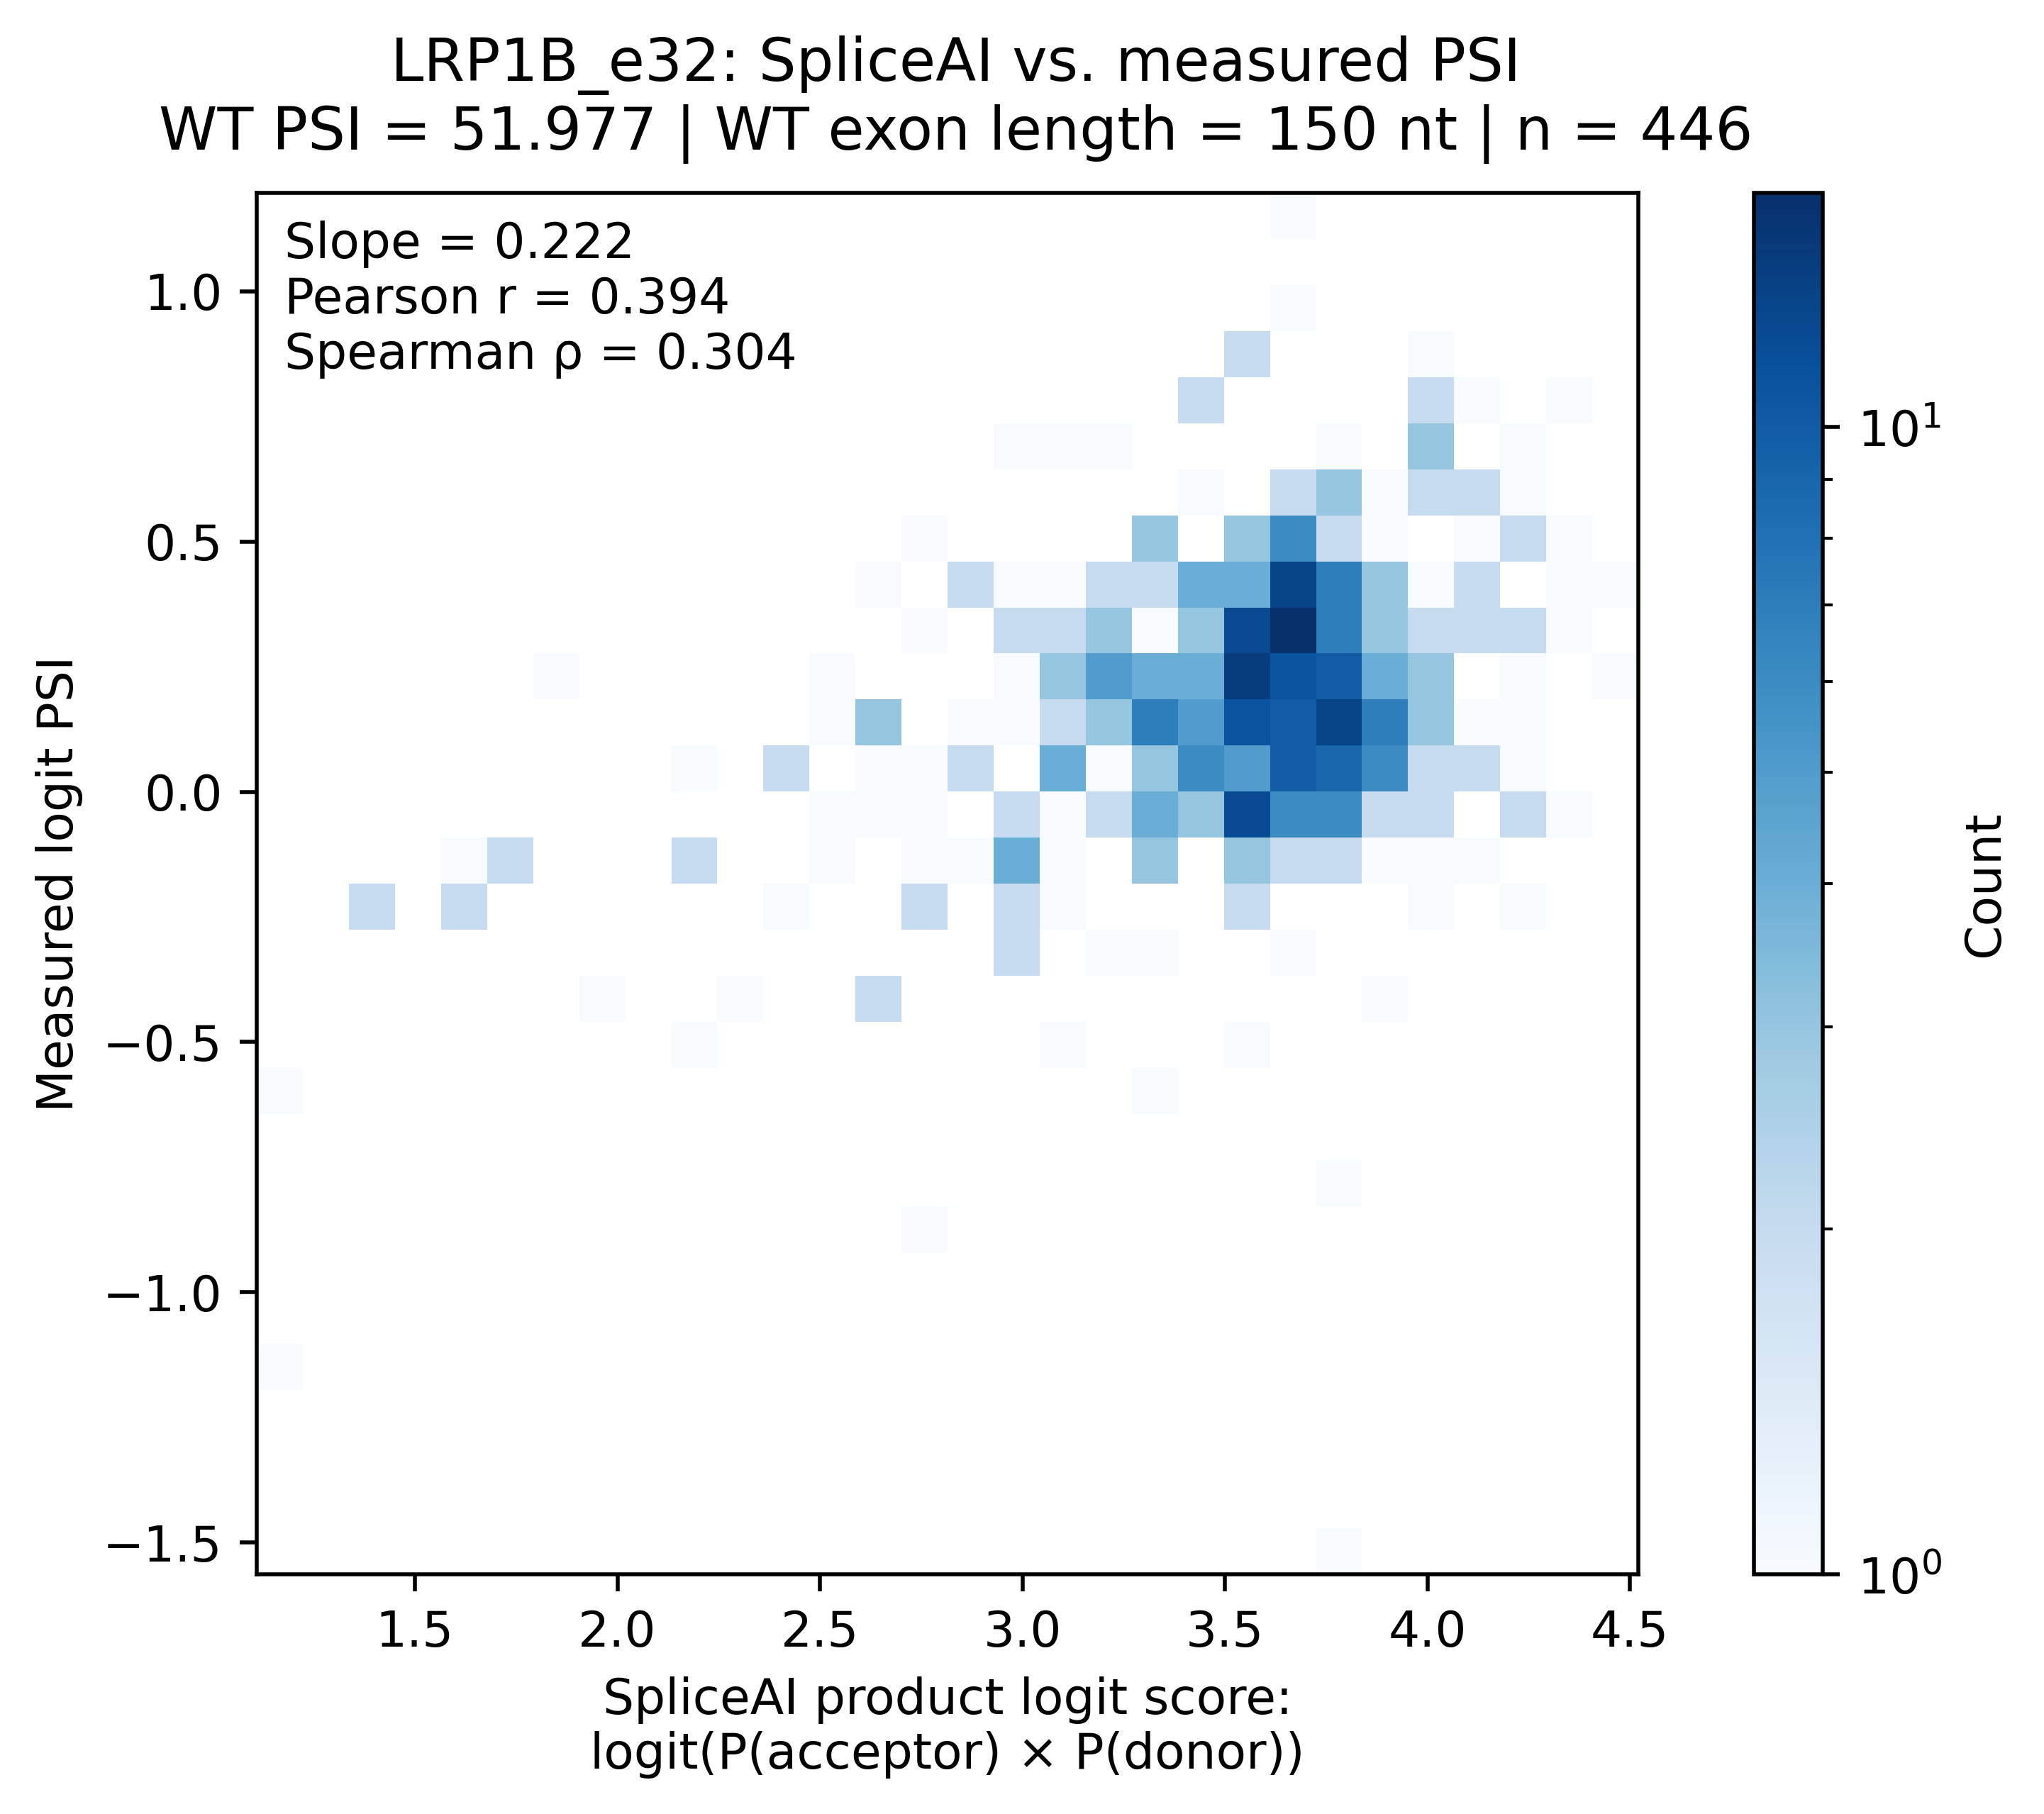

In [24]:
fig, axes = plot_spliceai_vs_psi(
    spliceai_preds,
    wt_exons,
    exon_id="LRP1B_e32",
    bins=30,
)

plt.show()

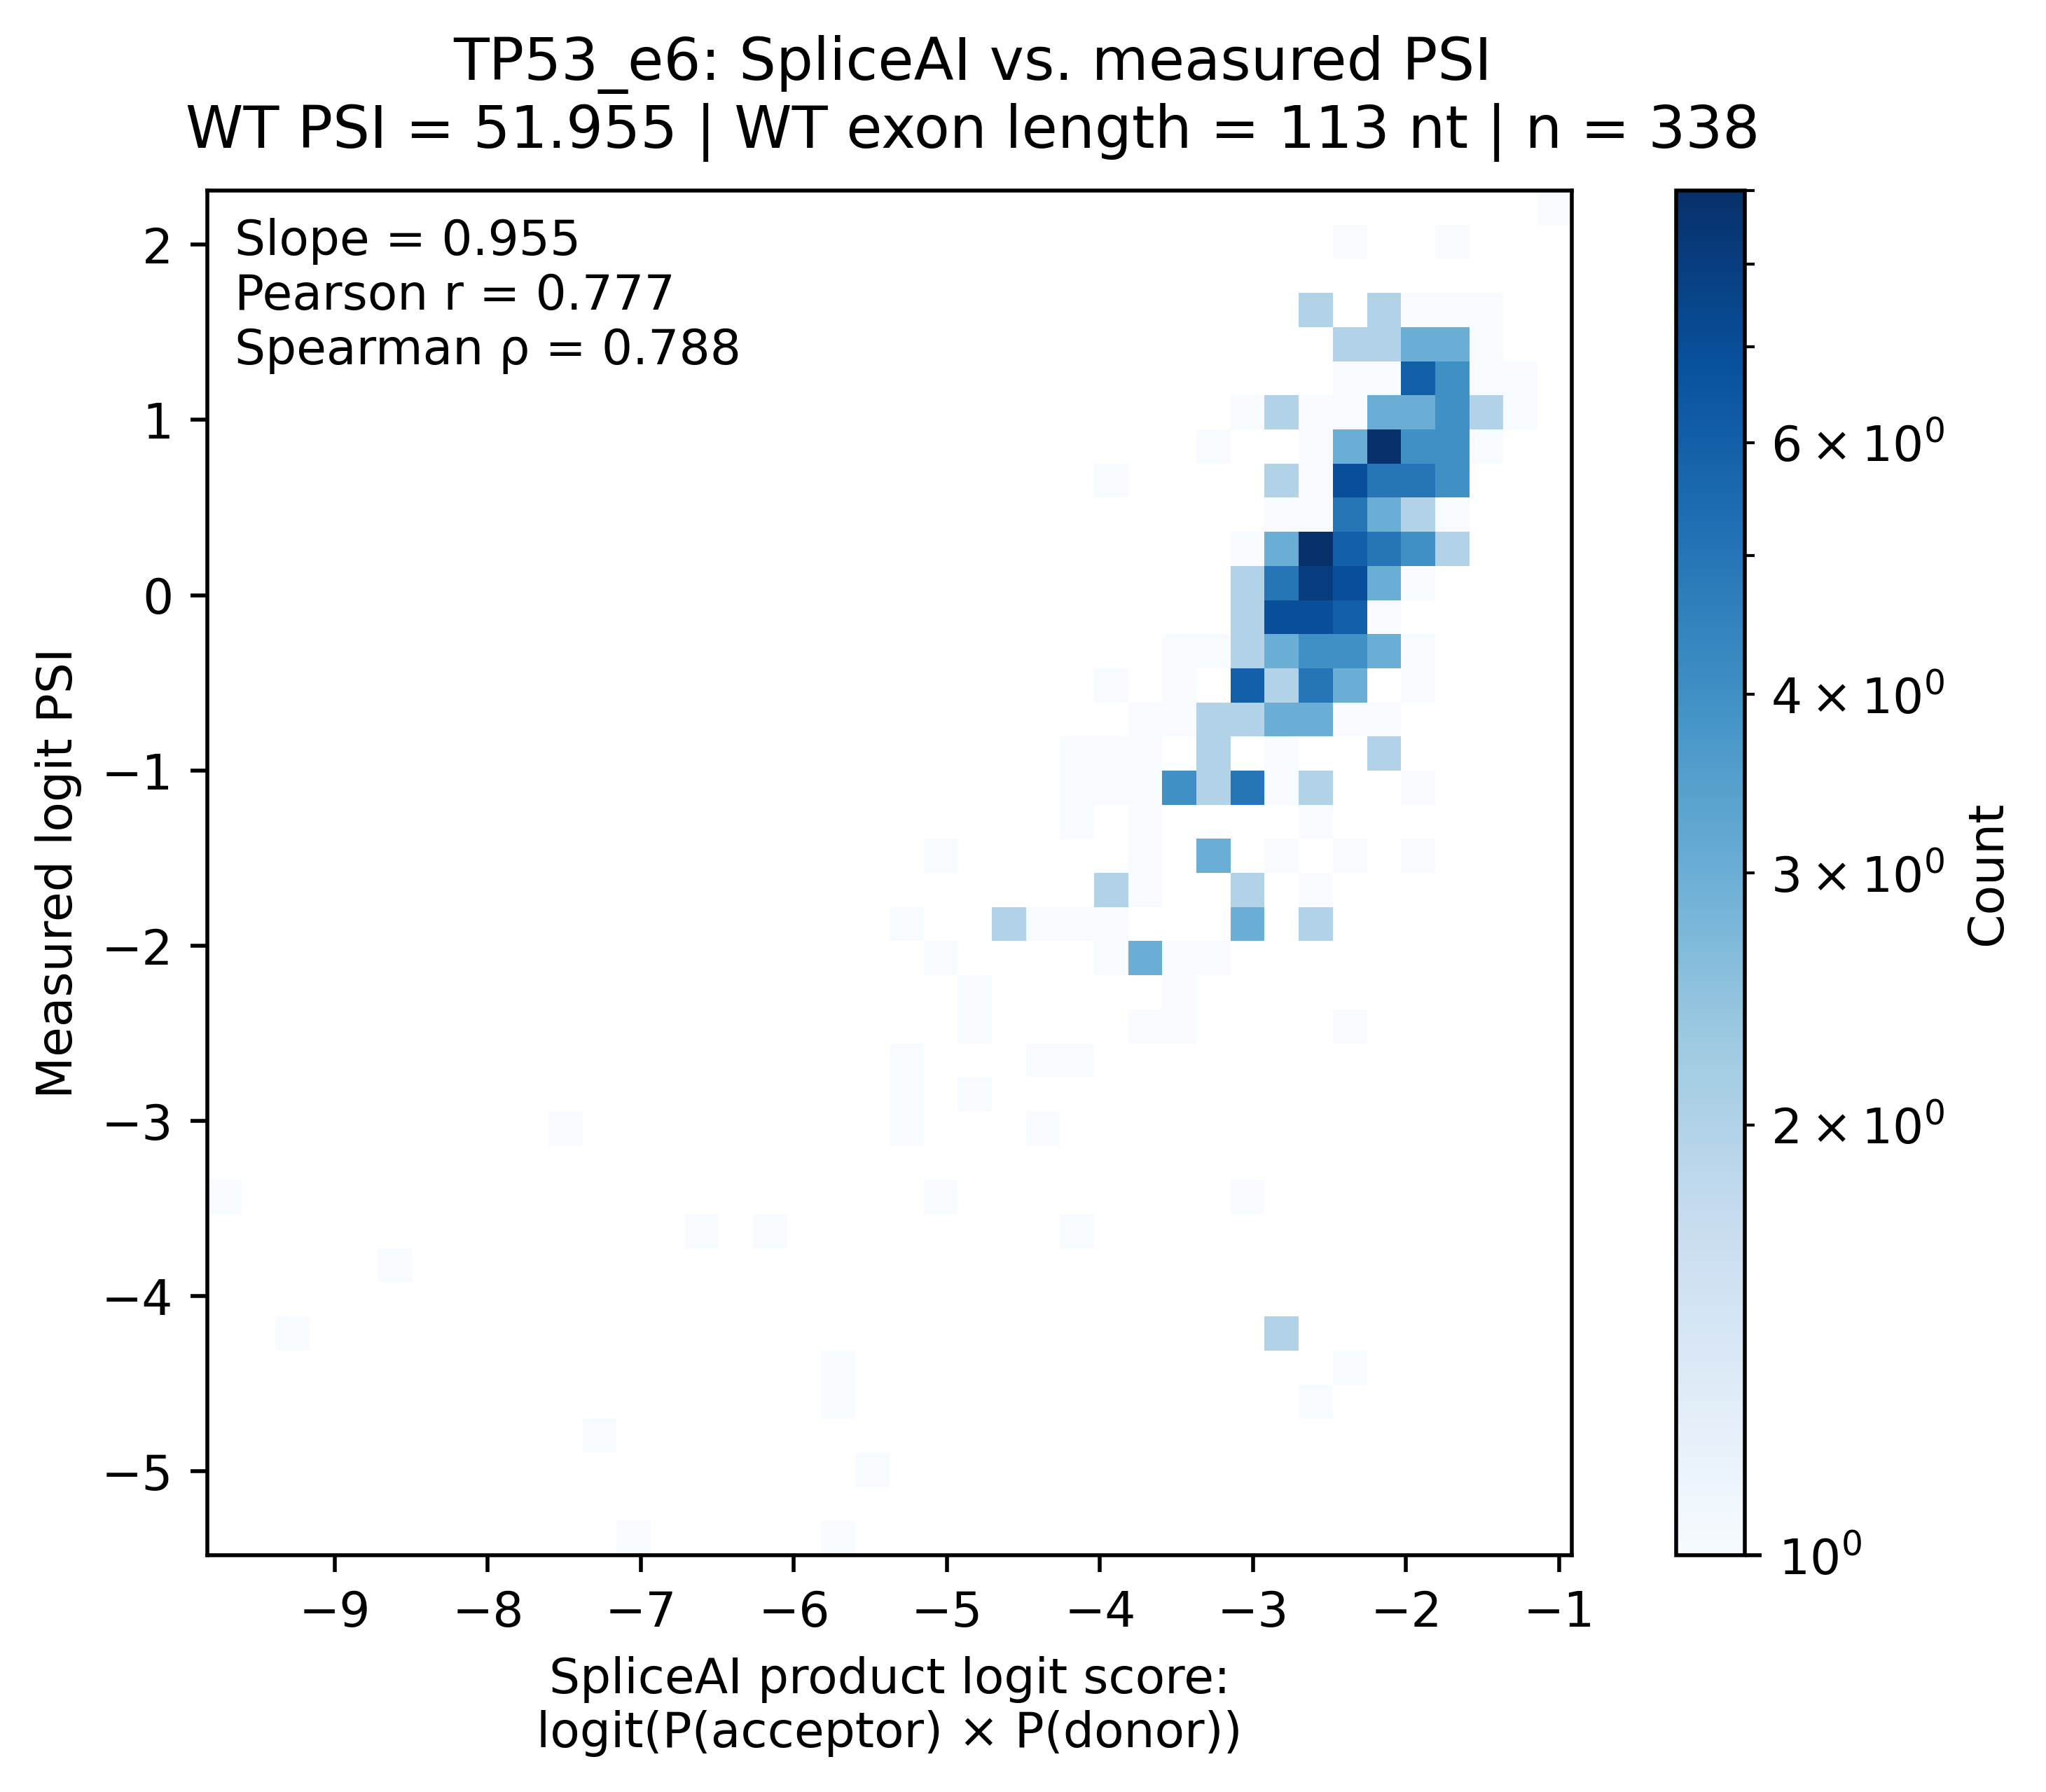

In [25]:
fig, axes = plot_spliceai_vs_psi(
    spliceai_preds,
    wt_exons,
    exon_id="TP53_e6",
    bins=40,
)

plt.show()

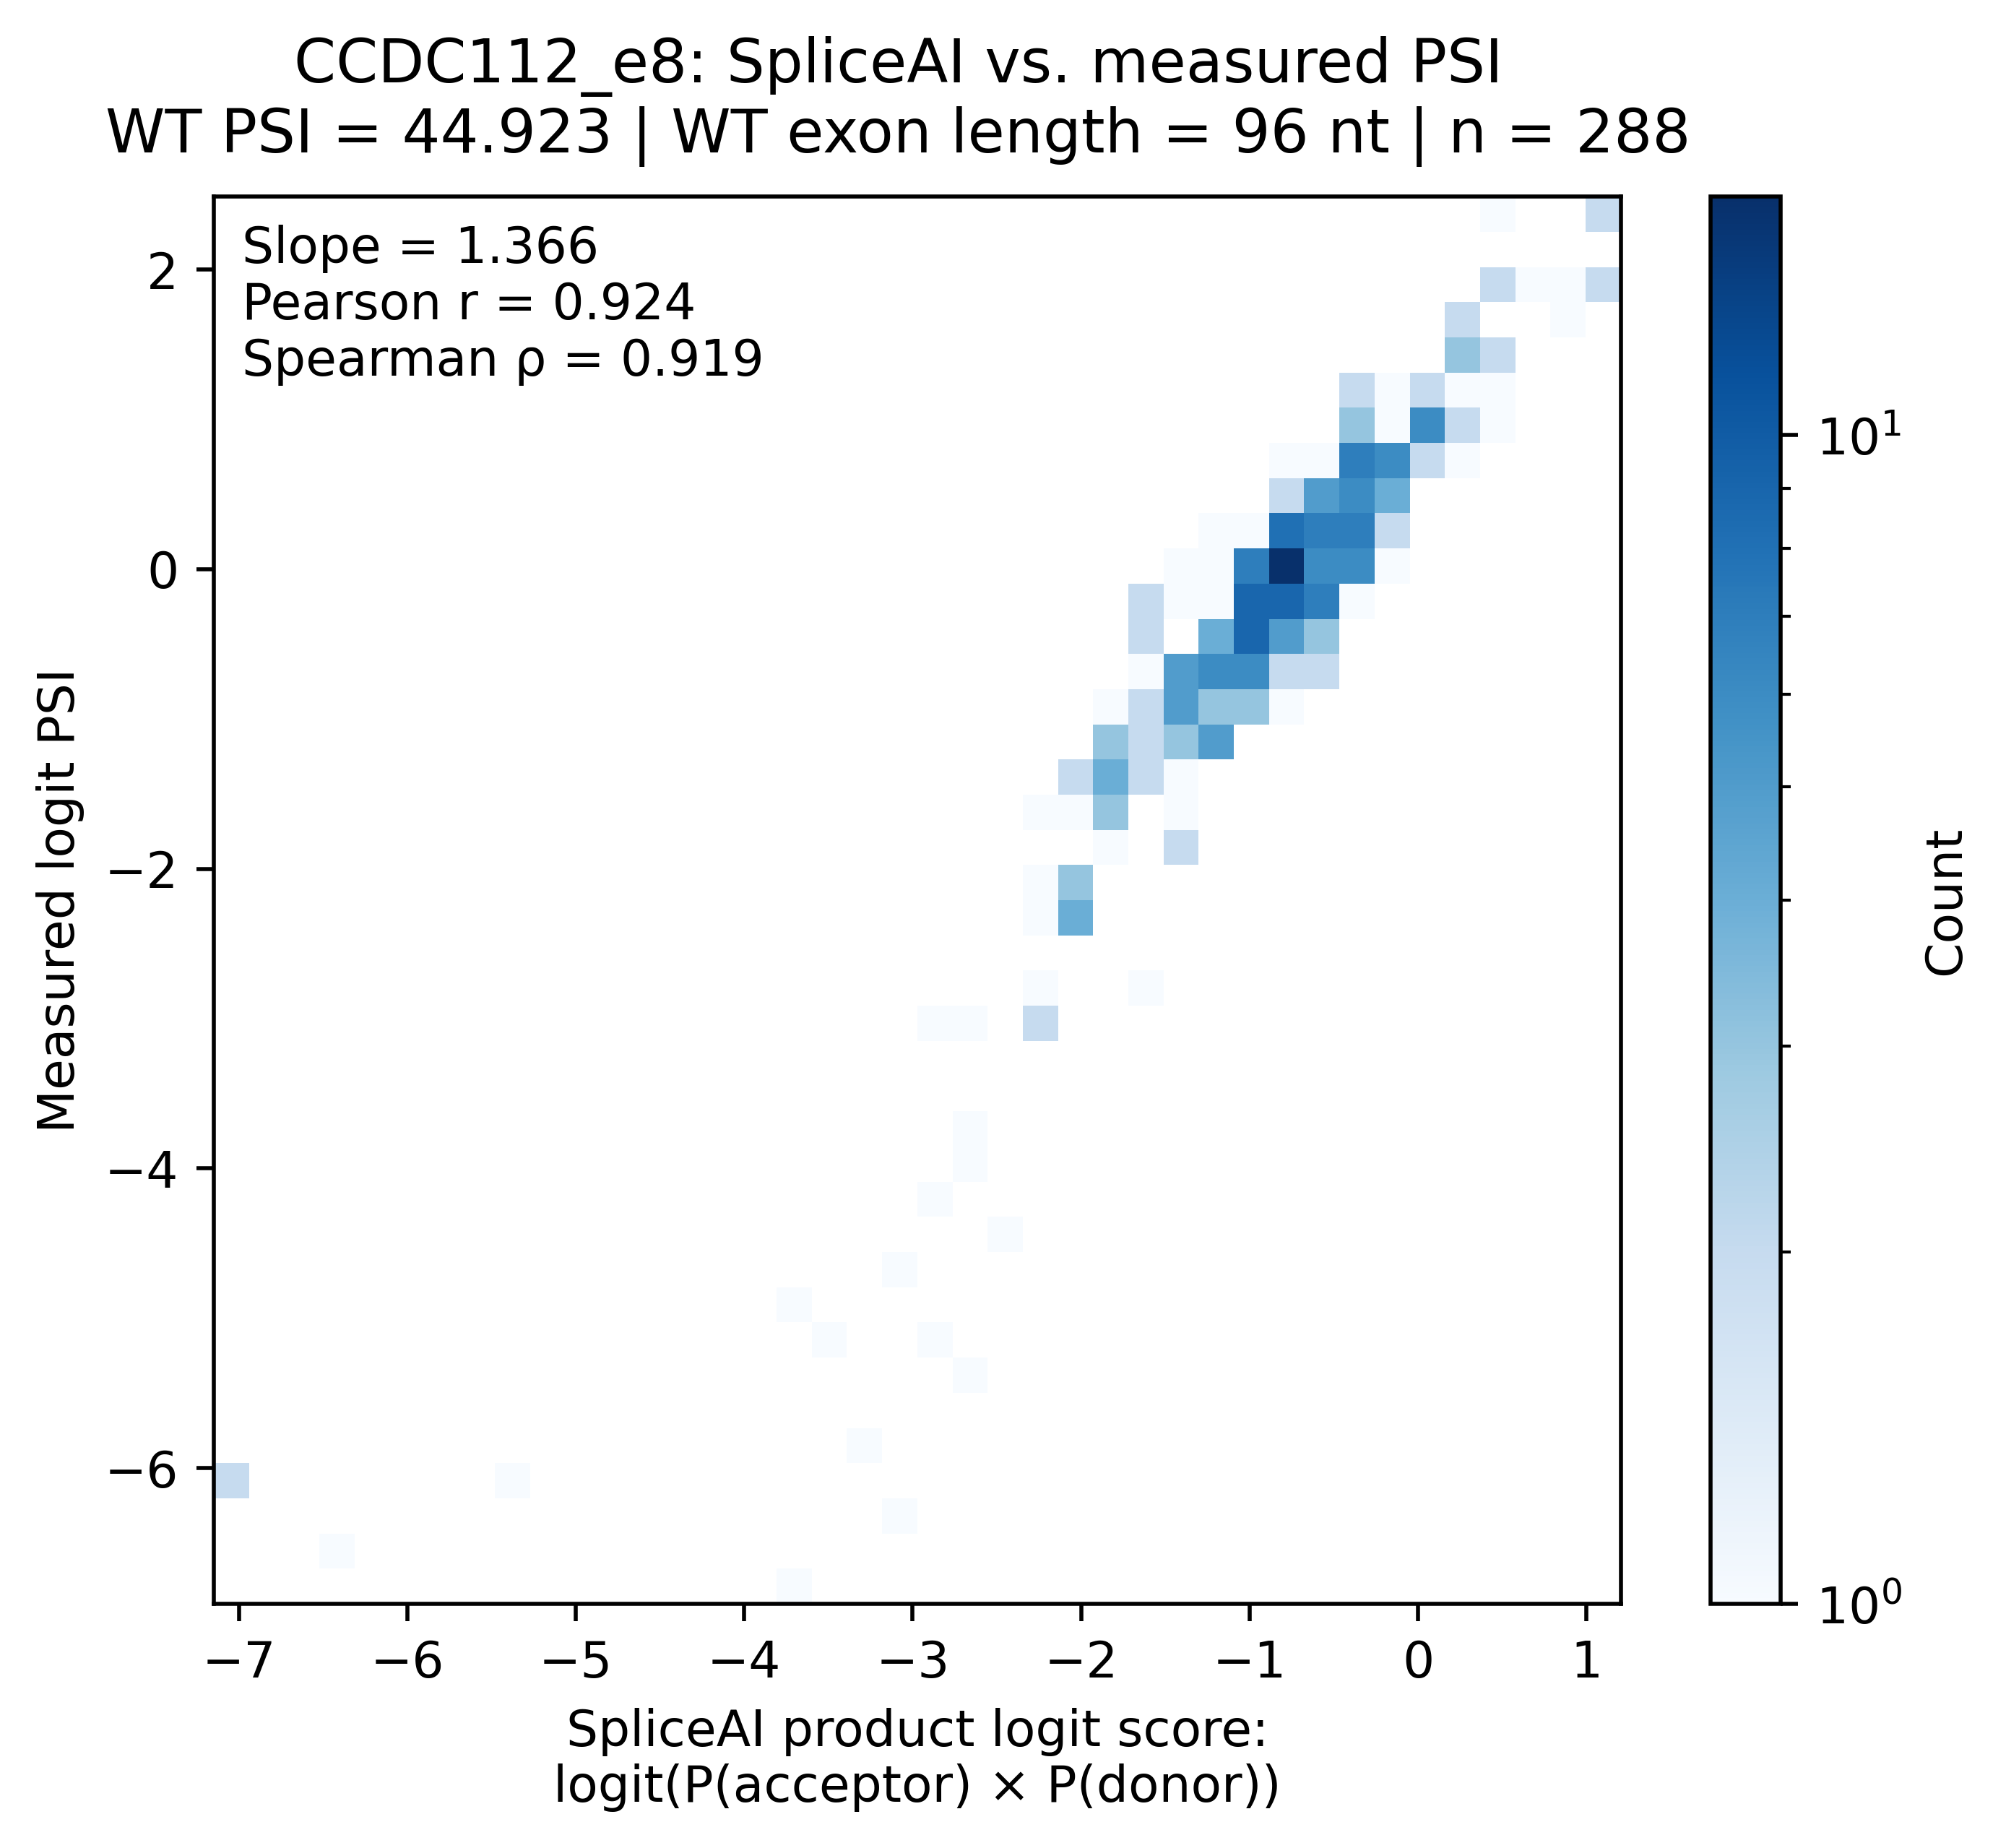

In [26]:
fig, axes = plot_spliceai_vs_psi(
    spliceai_preds,
    wt_exons,
    exon_id="CCDC112_e8",
    bins=40,
    kind="hist2d"
)

plt.show()

In [27]:
# ---------------------------------------------------------------------------
# Replicate reproducibility QC
# ---------------------------------------------------------------------------
# For each exon, rank-correlate the three PSI replicates pairwise across that
# exon's variants (using only variants where both replicates are non-null).
# The worst of the three correlations summarises how reproducible the exon's
# measurements are.

REPLICATE_PAIRS = [("psi_r1", "psi_r2"), ("psi_r1", "psi_r3"), ("psi_r2", "psi_r3")]


def compute_replicate_reproducibility(exonic_variants, min_pairs=10):
    """Per-exon pairwise Spearman rho between PSI replicates, and their minimum."""
    cols = ["exon_id"] + [c for pair in REPLICATE_PAIRS for c in pair]
    data = exonic_variants[list(dict.fromkeys(cols))]

    records = []
    for exon_id, grp in data.groupby("exon_id", sort=False):
        rec = {"exon_id": exon_id}
        rhos = []
        for a, b in REPLICATE_PAIRS:
            sub = grp[[a, b]].dropna()
            if len(sub) < min_pairs or sub[a].std() == 0 or sub[b].std() == 0:
                rho = np.nan
            else:
                rho = spearmanr(sub[a], sub[b]).statistic
            rec[f"rho_{a[-2:]}_{b[-2:]}"] = rho
            rec[f"n_{a[-2:]}_{b[-2:]}"] = len(sub)
            rhos.append(rho)
        rec["min_replicate_rho"] = np.nan if np.all(np.isnan(rhos)) else np.nanmin(rhos)
        records.append(rec)

    return pd.DataFrame.from_records(records).set_index("exon_id")


replicate_qc = compute_replicate_reproducibility(exonic_variants)
replicate_qc[
    ["rho_r1_r2", "rho_r1_r3", "rho_r2_r3", "min_replicate_rho"]
].describe()

,rho_r1_r2,rho_r1_r3,rho_r2_r3,min_replicate_rho
count,596.000000,596.000000,596.000000,596.000000
mean,0.693749,0.712287,0.703542,0.672625
std,0.293876,0.290183,0.295402,0.310954
min,-0.088887,-0.122663,-0.316426,-0.316426
25%,0.472297,0.507497,0.477121,0.428992
50%,0.815385,0.846555,0.837849,0.802553
75%,0.939441,0.949182,0.947742,0.932596
max,0.999343,0.998816,0.999143,0.998816


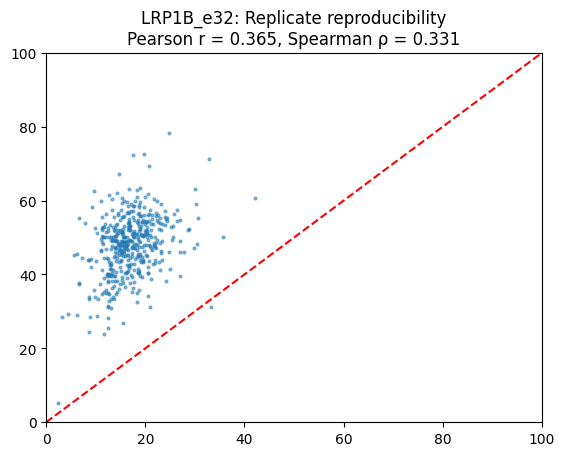

In [59]:
df = spliceai_preds[spliceai_preds.exon_id == "LRP1B_e32"]
plt.scatter(df['psi_r1'], df['psi_r3'], alpha=0.5, s=4)
pearson_r = pearsonr(df['psi_r1'], df['psi_r3']).statistic
spearman_rho = spearmanr(df['psi_r1'], df['psi_r3']).statistic
plt.title(f"LRP1B_e32: Replicate reproducibility\nPearson r = {pearson_r:.3f}, Spearman ρ = {spearman_rho:.3f}")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.plot([0, 100], [0, 100], color='red', linestyle='--')

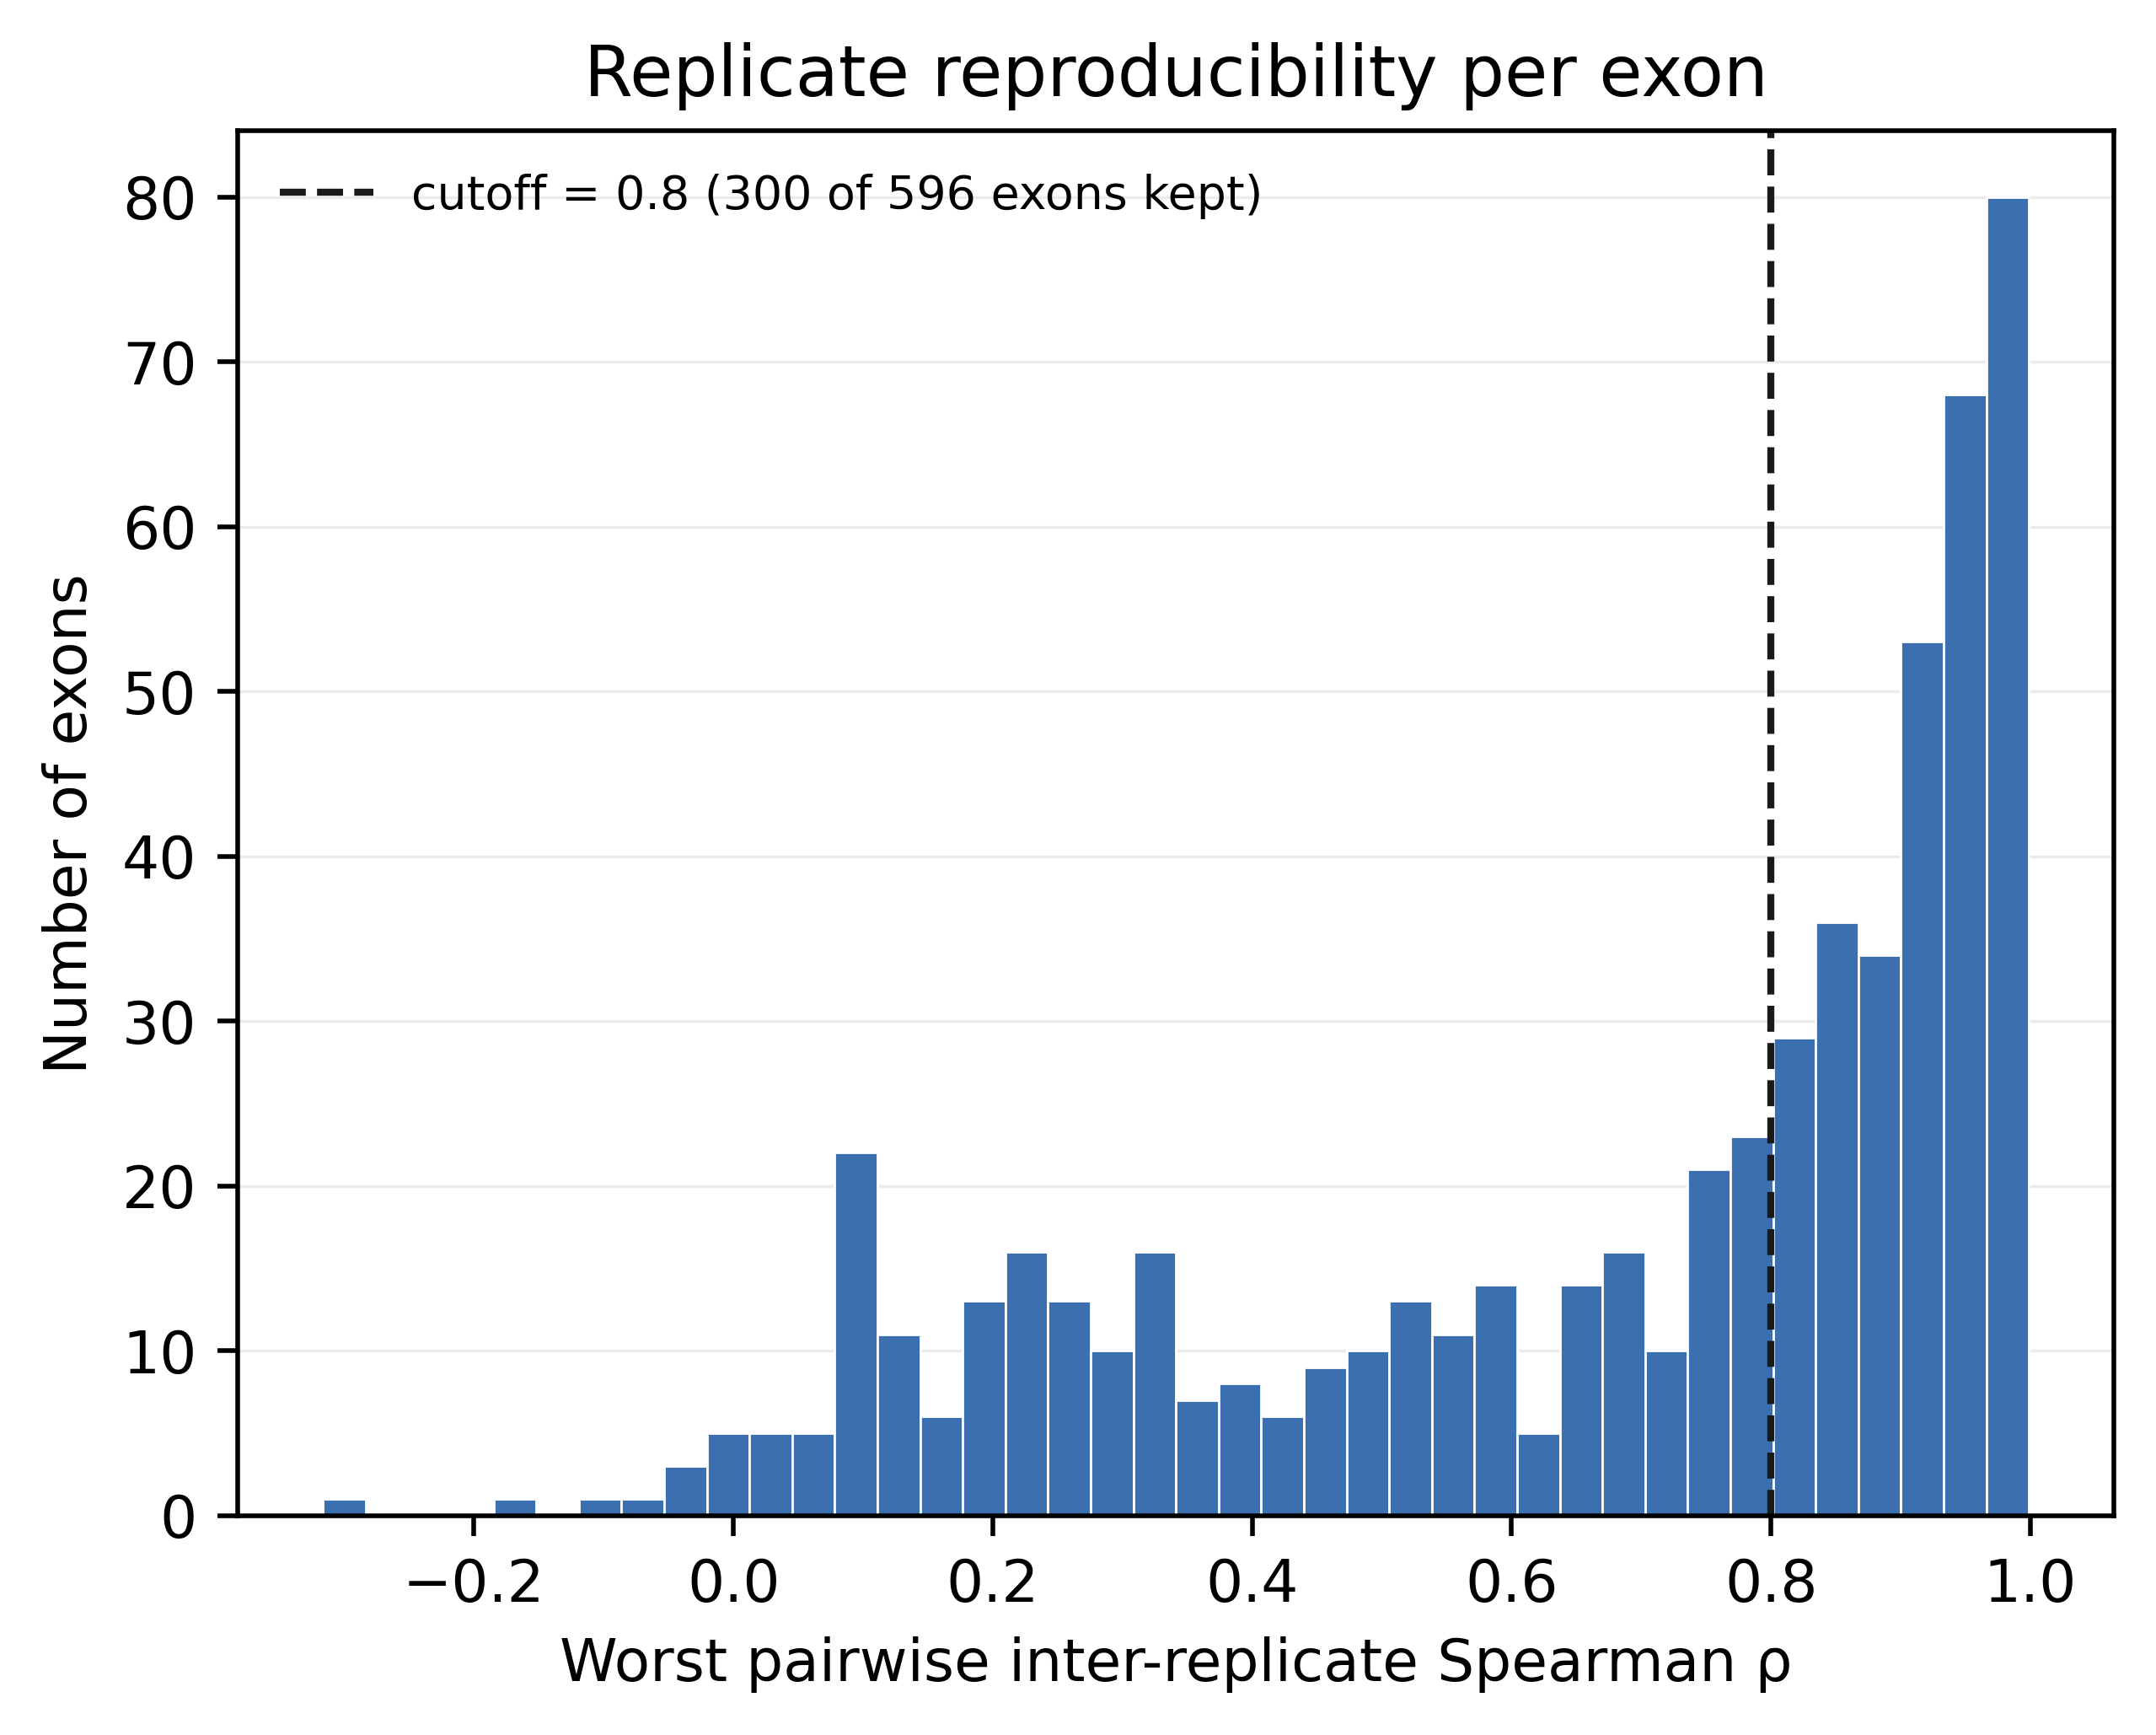

In [28]:
MIN_REPLICATE_RHO = 0.8

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True, dpi=500)
rho = replicate_qc["min_replicate_rho"].dropna()
kept = rho > MIN_REPLICATE_RHO
ax.hist(
    rho,
    bins=40,
    color="#3B6FB0",
    edgecolor="white",
    linewidth=0.4,
)
ax.axvline(
    MIN_REPLICATE_RHO,
    color="#1A1A1A",
    linestyle="--",
    linewidth=1.2,
    label=f"cutoff = {MIN_REPLICATE_RHO} ({kept.sum():,} of {len(rho):,} exons kept)",
)
ax.set_xlabel("Worst pairwise inter-replicate Spearman ρ")
ax.set_ylabel("Number of exons")
ax.set_title("Replicate reproducibility per exon")
ax.legend(frameon=False, fontsize=8)
ax.grid(axis="y", alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)
plt.show()

In [29]:
# ---------------------------------------------------------------------------
# Aggregate statistics across all exons
# ---------------------------------------------------------------------------
# For every exon we regress the measured logit PSI of its SNVs on the SpliceAI
# *product* logit score, logit(P(acceptor) x P(donor)), and record the Pearson r,
# Spearman rho and OLS slope of that fit.

def build_exon_metadata(exonic_variants, wt_exons, replicate_qc):
    """Per-exon table of WT exon length, WT (true) PSI and replicate QC."""
    lengths = (
        exonic_variants.drop_duplicates("exon_id")
        .set_index("exon_id")[["wt_exon_length"]]
    )
    wt = (
        wt_exons.set_index("exon_id")[["logit_psi", "psi"]]
        .rename(columns={"logit_psi": "wt_logit_psi", "psi": "wt_psi"})
    )
    return lengths.join(wt, how="inner").join(replicate_qc[["min_replicate_rho"]])


def compute_exon_stats(
    df,
    exonic_variants,
    wt_exons,
    replicate_qc,
    score_col="spliceai_prod_logit",
    min_wt_exon_length=30,
    min_variants=10,
    min_replicate_rho=MIN_REPLICATE_RHO,
):
    """Per-exon correlation / slope of measured logit PSI vs a SpliceAI score.

    Exons are kept only if they are long enough, have enough variants, and are
    reproducible across replicates (worst pairwise Spearman rho above the cutoff).

    Returns a DataFrame indexed by exon_id with n_variants, pearson_r,
    spearman_rho, slope, intercept, wt_logit_psi, wt_psi, wt_exon_length and
    min_replicate_rho.
    """
    meta = build_exon_metadata(exonic_variants, wt_exons, replicate_qc)

    data = (
        df[["exon_id", score_col, "logit_psi"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    records = []
    for exon_id, grp in data.groupby("exon_id", sort=False):
        x = grp[score_col].to_numpy()
        y = grp["logit_psi"].to_numpy()
        if len(grp) < min_variants or x.std() == 0 or y.std() == 0:
            continue
        fit = linregress(x, y)
        records.append(
            {
                "exon_id": exon_id,
                "n_variants": len(grp),
                "pearson_r": pearsonr(x, y).statistic,
                "spearman_rho": spearmanr(x, y).statistic,
                "slope": fit.slope,
                "intercept": fit.intercept,
            }
        )

    stats = pd.DataFrame.from_records(records).set_index("exon_id")
    stats = stats.join(meta, how="inner")

    n_all = stats.shape[0]
    stats = stats.loc[stats["wt_exon_length"] >= min_wt_exon_length]
    n_long = stats.shape[0]
    stats = stats.loc[stats["min_replicate_rho"] > min_replicate_rho]
    print(
        f"{data['exon_id'].nunique():,} exons with usable variants -> "
        f"{n_all:,} passed n >= {min_variants} -> "
        f"{n_long:,} passed wt_exon_length >= {min_wt_exon_length} -> "
        f"{len(stats):,} passed min_replicate_rho > {min_replicate_rho}"
    )
    return stats.sort_values("pearson_r", ascending=False)

In [35]:
replicate_qc.loc["LRP1B_e32"]

rho_r1_r2              0.217561
n_r1_r2              446.000000
rho_r1_r3              0.330633
n_r1_r3              446.000000
rho_r2_r3              0.308095
n_r2_r3              446.000000
min_replicate_rho      0.217561
Name: LRP1B_e32, dtype: float64

In [30]:
exon_stats = compute_exon_stats(spliceai_preds, exonic_variants, wt_exons, replicate_qc)
exon_stats[
    ["n_variants", "pearson_r", "spearman_rho", "slope", "min_replicate_rho"]
].describe()

601 exons with usable variants -> 597 passed n >= 10 -> 566 passed wt_exon_length >= 30 -> 282 passed min_replicate_rho > 0.8


,n_variants,pearson_r,spearman_rho,slope,min_replicate_rho
count,282.000000,282.000000,282.000000,282.000000,282.000000
mean,245.535461,0.791715,0.785714,1.154005,0.919215
std,96.662088,0.119934,0.109113,0.347946,0.054920
min,15.000000,0.309421,0.374389,0.426533,0.801690
25%,153.000000,0.731915,0.722194,0.931717,0.877205
50%,267.000000,0.825248,0.815405,1.130294,0.930766
75%,319.250000,0.882312,0.864260,1.358353,0.965460
max,447.000000,0.953979,0.939451,2.290571,0.998816


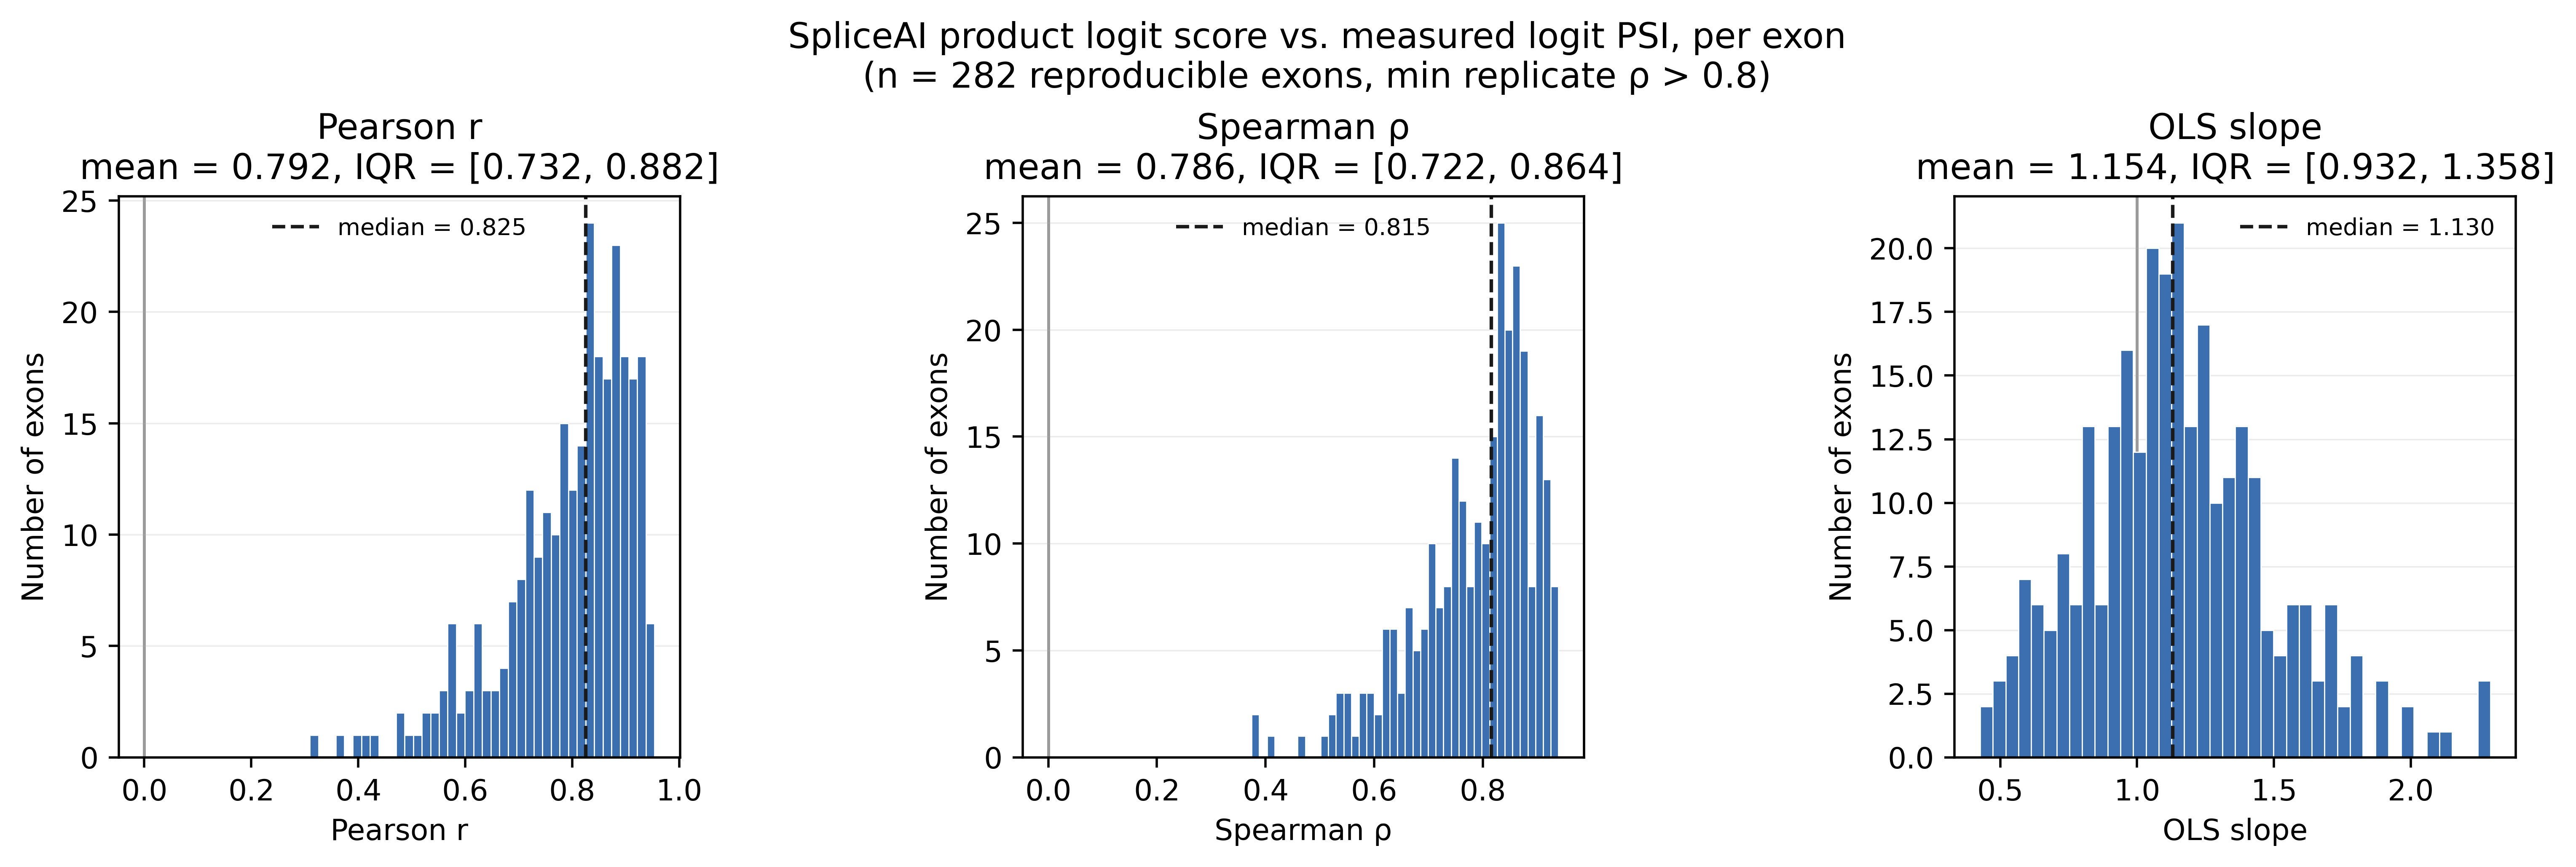

In [31]:
STATS = [
    ("pearson_r", "Pearson r", 0.0),
    ("spearman_rho", "Spearman ρ", 0.0),
    ("slope", "OLS slope", 1.0),
]
ACCENT = "#3B6FB0"


def plot_stat_histograms(stats, bins=40, figsize=(13, 4)):
    """One histogram per aggregate statistic."""
    fig, axes = plt.subplots(
        1, len(STATS), figsize=figsize, constrained_layout=True, dpi=500
    )
    fig.suptitle(
        "SpliceAI product logit score vs. measured logit PSI, per exon\n"
        f"(n = {len(stats):,} reproducible exons, min replicate ρ > {MIN_REPLICATE_RHO})"
    )

    for ax, (col, label, ref) in zip(axes, STATS):
        values = stats[col]
        ax.hist(values, bins=bins, color=ACCENT, edgecolor="white", linewidth=0.4)
        ax.axvline(
            values.median(),
            color="#1A1A1A",
            linestyle="--",
            linewidth=1.2,
            label=f"median = {values.median():.3f}",
        )
        ax.axvline(ref, color="#9A9A9A", linewidth=1.0, zorder=0)
        ax.set_xlabel(label)
        ax.set_ylabel("Number of exons")
        ax.set_title(
            f"{label}\nmean = {values.mean():.3f}, IQR = "
            f"[{values.quantile(0.25):.3f}, {values.quantile(0.75):.3f}]"
        )
        ax.legend(frameon=False, fontsize=8)
        ax.grid(axis="y", alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.set_box_aspect(1)

    return fig, axes


fig, axes = plot_stat_histograms(exon_stats)
plt.show()

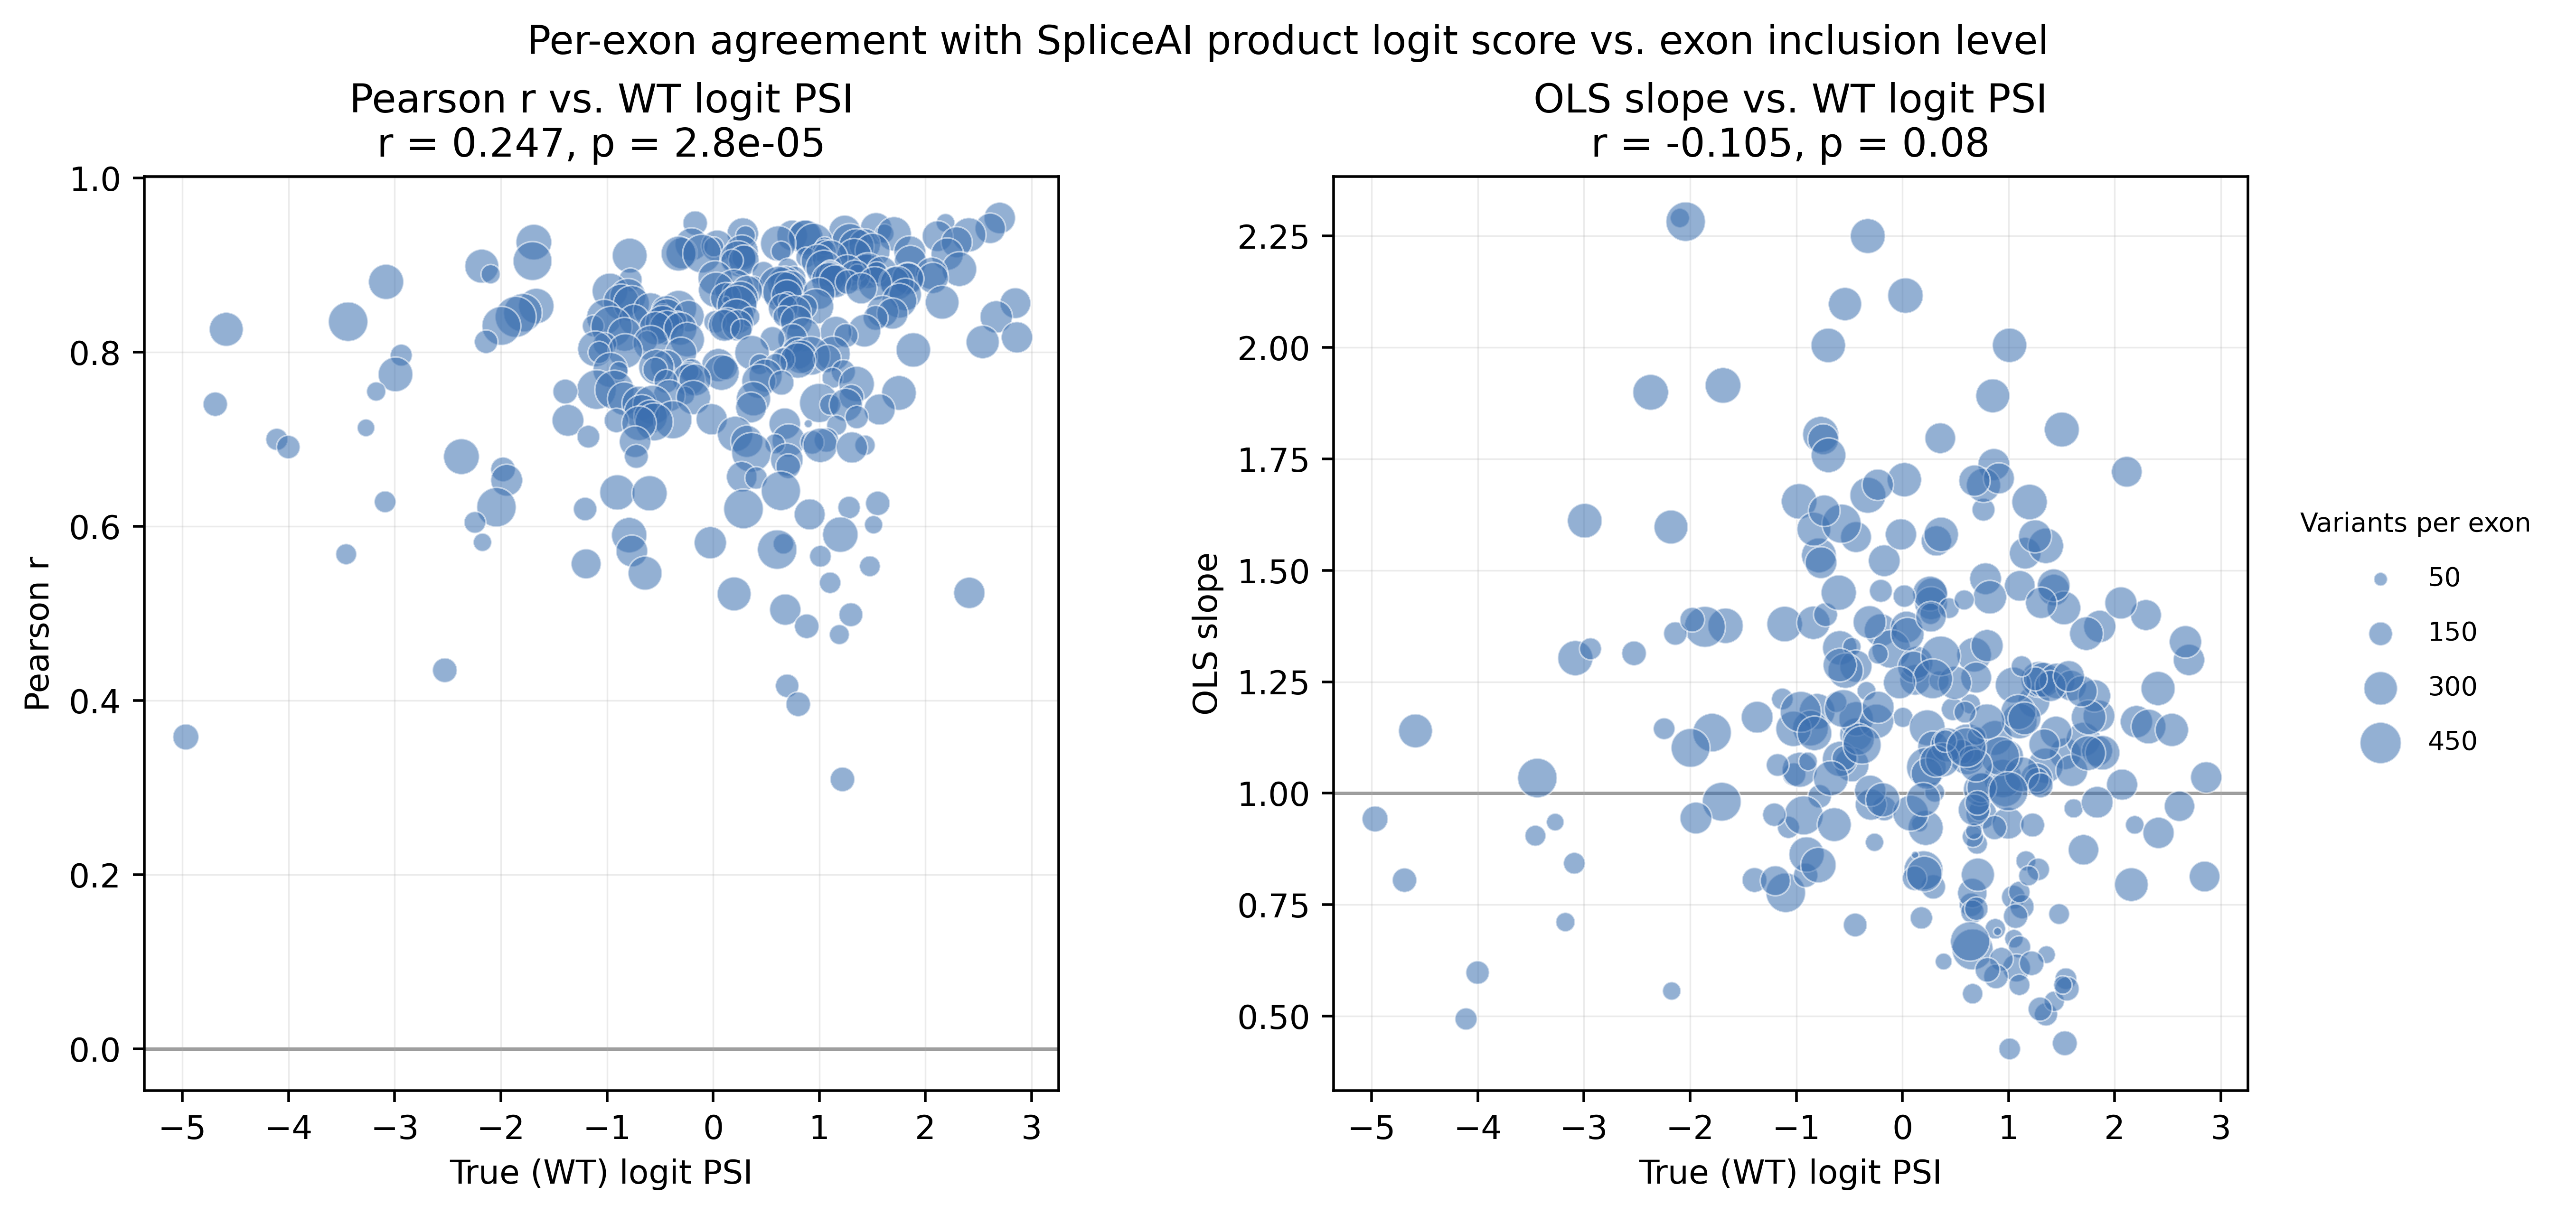

In [32]:
def plot_stat_vs_wt_psi(stats, size_scale=0.35, figsize=(11, 5)):
    """Per-exon statistic against the exon's true (WT) logit PSI.

    Marker area is proportional to the number of variants for that exon.
    """
    panels = [
        ("pearson_r", "Pearson r", 0.0),
        ("slope", "OLS slope", 1.0),
    ]
    sizes = stats["n_variants"] * size_scale

    fig, axes = plt.subplots(
        1, len(panels), figsize=figsize, constrained_layout=True, dpi=500
    )
    fig.suptitle(
        "Per-exon agreement with SpliceAI product logit score vs. exon inclusion level"
    )

    for ax, (col, label, ref) in zip(axes, panels):
        ax.axhline(ref, color="#9A9A9A", linewidth=1.0, zorder=0)
        ax.scatter(
            stats["wt_logit_psi"],
            stats[col],
            s=sizes,
            color=ACCENT,
            alpha=0.55,
            edgecolor="white",
            linewidth=0.5,
        )
        r = pearsonr(stats["wt_logit_psi"], stats[col])
        ax.set_xlabel("True (WT) logit PSI")
        ax.set_ylabel(label)
        ax.set_title(f"{label} vs. WT logit PSI\nr = {r.statistic:.3f}, p = {r.pvalue:.2g}")
        ax.grid(alpha=0.25, linewidth=0.5)
        ax.set_axisbelow(True)
        ax.set_box_aspect(1)

    # size legend: marker area is proportional to variant count
    ticks = [50, 150, 300, 450]
    handles = [
        plt.scatter(
            [], [], s=t * size_scale, color=ACCENT, alpha=0.55,
            edgecolor="white", linewidth=0.5, label=f"{t}",
        )
        for t in ticks
    ]
    axes[-1].legend(
        handles=handles,
        title="Variants per exon",
        frameon=False,
        fontsize=8,
        title_fontsize=8,
        labelspacing=1.1,
        borderpad=0.8,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
    )

    return fig, axes


fig, axes = plot_stat_vs_wt_psi(exon_stats)
plt.show()